# 빅데이터 처리와 시각화 12장 - Final Review

**시험 범위: 강의노트 7장 ~ 10장 (9장·10장은 섹션 4까지)**

시험은 기본 코드를 기반으로 출제됨.


## 데이터 정제 및 분석 파트

In [3]:
import pandas as pd
import numpy as np

> #### Exercise
> 아래 `df_ex1` 데이터를 사용하여 다음을 수행하시오.
> 1. 각 컬럼별 결측치 수와 결측치 비율(%)을 출력하시오.
> 2. `점수` 컬럼의 결측치를 **중앙값**으로 채우시오.
> 3. `도시` 컬럼의 결측치를 **최빈값**으로 채우시오.
> 4. `방문횟수` 컬럼의 결측치가 있는 행을 **제거**하시오.


In [5]:
df_ex1 = pd.DataFrame({
    '고객명': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
    '도시': ['서울', '부산', None, '서울', '대구', None, '서울', '부산'],
    '점수': [85, None, 72, 90, None, 68, 88, None],
    '방문횟수': [5, 3, None, 8, 2, None, 4, 6]
})
display(df_ex1)

# 1. 결측치 수와 비율
print('--- 결측치 수 ---')
print(df_ex1.isnull().sum())
print('\n--- 결측치 비율 (%) ---')
print((df_ex1.isnull().sum() / len(df_ex1) * 100).round(1))

# 2. 점수: 중앙값으로 채우기
score_median = df_ex1['점수'].median()
df_ex1['점수'] = df_ex1['점수'].fillna(score_median)
print(f'\n점수 중앙값: {score_median}')

# 3. 도시: 최빈값으로 채우기
city_mode = df_ex1['도시'].mode()[0]
df_ex1['도시'] = df_ex1['도시'].fillna(city_mode)
print(f'도시 최빈값: {city_mode}')

# 4. 방문횟수: 결측치 있는 행 제거
df_ex1 = df_ex1.dropna(subset=['방문횟수'])

print('\n--- 최종 결과 ---')
display(df_ex1)
print(f'결측치 수:\n{df_ex1.isnull().sum()}')


,고객명,도시,점수,방문횟수
0,A,서울,85.0,5.0
1,B,부산,NaN,3.0
2,C,NaN,72.0,NaN
3,D,서울,90.0,8.0
4,E,대구,NaN,2.0
5,F,NaN,68.0,NaN
6,G,서울,88.0,4.0
7,H,부산,NaN,6.0


--- 결측치 수 ---
고객명     0
도시      2
점수      3
방문횟수    2
dtype: int64

--- 결측치 비율 (%) ---
고객명      0.0
도시      25.0
점수      37.5
방문횟수    25.0
dtype: float64

점수 중앙값: 85.0
도시 최빈값: 서울

--- 최종 결과 ---


,고객명,도시,점수,방문횟수
0,A,서울,85.0,5.0
1,B,부산,85.0,3.0
3,D,서울,90.0,8.0
4,E,대구,85.0,2.0
6,G,서울,88.0,4.0
7,H,부산,85.0,6.0


결측치 수:
고객명     0
도시      0
점수      0
방문횟수    0
dtype: int64


In [6]:
df_adv1 = pd.DataFrame({
    '날짜': pd.date_range('2024-01-01', periods=10),
    '서울': [2.1, None, 3.5, 4.0, None, 5.2, 5.8, None, 6.3, 7.0],
    '부산': [8.5, 9.0, None, 10.1, 10.5, None, 11.2, 11.8, None, 12.5],
    '제주': [None, None, None, 15.0, None, None, None, 17.0, None, None]
})
display(df_adv1)

# 결측치 비율 계산
null_ratio = df_adv1.isnull().sum() / len(df_adv1) * 100
print('--- 컬럼별 결측치 비율 (%) ---')
print(null_ratio)

# 30% 이상인 컬럼 제거
cols_to_drop = null_ratio[null_ratio >= 30].index.tolist()
print(f'\n제거할 컬럼 (결측치 30% 이상): {cols_to_drop}')
df_adv1 = df_adv1.drop(columns=cols_to_drop)

# 나머지 결측치는 선형 보간
numeric_cols = df_adv1.select_dtypes(include='number').columns
df_adv1[numeric_cols] = df_adv1[numeric_cols].interpolate(method='linear')

print('\n--- 보간 후 결과 ---')
display(df_adv1)
print(f'\n결측치 수:\n{df_adv1.isnull().sum()}')


,날짜,서울,부산,제주
0,2024-01-01,2.1,8.5,NaN
1,2024-01-02,NaN,9.0,NaN
2,2024-01-03,3.5,NaN,NaN
3,2024-01-04,4.0,10.1,15.0
4,2024-01-05,NaN,10.5,NaN
5,2024-01-06,5.2,NaN,NaN
6,2024-01-07,5.8,11.2,NaN
7,2024-01-08,NaN,11.8,17.0
8,2024-01-09,6.3,NaN,NaN
9,2024-01-10,7.0,12.5,NaN


--- 컬럼별 결측치 비율 (%) ---
날짜     0.0
서울    30.0
부산    30.0
제주    80.0
dtype: float64

제거할 컬럼 (결측치 30% 이상): ['서울', '부산', '제주']

--- 보간 후 결과 ---


,날짜
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05
5,2024-01-06
6,2024-01-07
7,2024-01-08
8,2024-01-09
9,2024-01-10



결측치 수:
날짜    0
dtype: int64


> #### Exercise
> 아래 `df_ex2` 데이터에서 다음을 수행하시오.
> 1. 전체 컬럼 기준으로 완전히 동일한 중복 행의 수를 출력하시오.
> 2. `주문ID` 컬럼 기준으로 중복된 행을 찾아서 출력하시오.
> 3. `주문ID` 기준 중복 제거 후, 가장 최신 주문(마지막 행)만 남기시오.

```python
df_ex2 = pd.DataFrame({
    '주문ID': ['A001', 'A002', 'A001', 'A003', 'A002', 'A004'],
    '고객':   ['김철수', '이영희', '김철수', '박민수', '이영희', '최지우'],
    '상품':   ['노트북', '마우스', '노트북', '모니터', '키보드', '웹캠'],
    '금액':   [1200000, 35000, 1200000, 250000, 120000, 85000]
})
```

In [8]:
df_ex2 = pd.DataFrame({
    '주문ID': ['A001', 'A002', 'A001', 'A003', 'A002', 'A004'],
    '고객':   ['김철수', '이영희', '김철수', '박민수', '이영희', '최지우'],
    '상품':   ['노트북', '마우스', '노트북', '모니터', '키보드', '웹캠'],
    '금액':   [1200000, 35000, 1200000, 250000, 120000, 85000]
})
display(df_ex2)

# 1. 전체 컬럼 기준 완전히 동일한 중복 행 수
total_dup_count = df_ex2.duplicated().sum()
print(f'1. 완전 중복 행 수: {total_dup_count}개')

# 2. 주문ID 기준 중복 행 출력
print('\n2. 주문ID 기준 중복된 행 (연루된 모든 행):')
display(df_ex2[df_ex2.duplicated(subset=['주문ID'], keep=False)])

# 3. 주문ID 기준 중복 제거 (마지막 행 = 최신 주문 유지)
df_ex2_clean = df_ex2.drop_duplicates(subset=['주문ID'], keep='last')
print('\n3. 중복 제거 후 (최신 주문 유지):')
display(df_ex2_clean.reset_index(drop=True))


,주문ID,고객,상품,금액
0,A001,김철수,노트북,1200000
1,A002,이영희,마우스,35000
2,A001,김철수,노트북,1200000
3,A003,박민수,모니터,250000
4,A002,이영희,키보드,120000
5,A004,최지우,웹캠,85000


1. 완전 중복 행 수: 1개

2. 주문ID 기준 중복된 행 (연루된 모든 행):


,주문ID,고객,상품,금액
0,A001,김철수,노트북,1200000
1,A002,이영희,마우스,35000
2,A001,김철수,노트북,1200000
4,A002,이영희,키보드,120000



3. 중복 제거 후 (최신 주문 유지):


,주문ID,고객,상품,금액
0,A001,김철수,노트북,1200000
1,A003,박민수,모니터,250000
2,A002,이영희,키보드,120000
3,A004,최지우,웹캠,85000


> #### Exercise
> 아래 `df_ex3` 데이터를 보고 다음을 수행하시오.
> 1. 각 컬럼의 데이터 타입을 확인하시오.
> 2. `판매량` 컬럼을 정수형(int)으로 변환하시오. (단, 변환 불가한 값은 NaN으로 처리 후 0으로 채울 것)
> 3. `단가` 컬럼을 실수형(float)으로 변환하시오.
> 4. `판매량 × 단가`로 `매출` 컬럼을 새로 추가하시오.


In [10]:
df_ex3 = pd.DataFrame({
    '상품': ['A', 'B', 'C', 'D', 'E'],
    '판매량': ['100', '200', '미입력', '150', '300'],
    '단가': ['5000', '3000', '8000', '4500', '2000']
})
display(df_ex3)

# 1. 데이터 타입 확인
print('--- 변환 전 데이터 타입 ---')
print(df_ex3.dtypes)

# 2. 판매량: to_numeric으로 변환 (변환 불가 → NaN → 0으로 채우기)
df_ex3['판매량'] = pd.to_numeric(df_ex3['판매량'], errors='coerce').fillna(0).astype(int)
print(f'\n판매량 변환 후: {df_ex3["판매량"].tolist()}')

# 3. 단가: float으로 변환
df_ex3['단가'] = df_ex3['단가'].astype(float)

# 4. 매출 컬럼 추가
df_ex3['매출'] = df_ex3['판매량'] * df_ex3['단가']

print('\n--- 변환 후 데이터 타입 ---')
print(df_ex3.dtypes)
print('\n--- 최종 결과 ---')
display(df_ex3)


,상품,판매량,단가
0,A,100,5000
1,B,200,3000
2,C,미입력,8000
3,D,150,4500
4,E,300,2000


--- 변환 전 데이터 타입 ---
상품     str
판매량    str
단가     str
dtype: object

판매량 변환 후: [100, 200, 0, 150, 300]

--- 변환 후 데이터 타입 ---
상품         str
판매량      int64
단가     float64
매출     float64
dtype: object

--- 최종 결과 ---


,상품,판매량,단가,매출
0,A,100,5000.0,500000.0
1,B,200,3000.0,600000.0
2,C,0,8000.0,0.0
3,D,150,4500.0,675000.0
4,E,300,2000.0,600000.0


> #### Exercise
> 아래 `df_ex4` 데이터를 사용하여 다음을 수행하시오.
> 1. `주소` 컬럼에서 '서울'이 포함된 고객만 필터링하시오.
> 2. `상품코드` 컬럼에서 `'-'`를 기준으로 분리하여 `카테고리`(앞부분)와 `번호`(뒷부분) 컬럼을 만드시오.
> 3. `고객명` 컬럼의 앞뒤 공백을 제거하시오.

```python
df_ex4 = pd.DataFrame({
    '고객명': ['  김철수', '이영희  ', ' 박민수 ', '최지우', '  안다솜'],
    '주소': ['서울시 강남구', '부산시 해운대구', '서울시 마포구', '대구시 중구', '서울시 종로구'],
    '상품코드': ['ELEC-001', 'ACC-002', 'ELEC-003', 'ACC-004', 'ELEC-005']
})
```

In [12]:
df_ex4 = pd.DataFrame({
    '고객명': ['  김철수', '이영희  ', ' 박민수 ', '최지우', '  안다솜'],
    '주소': ['서울시 강남구', '부산시 해운대구', '서울시 마포구', '대구시 중구', '서울시 종로구'],
    '상품코드': ['ELEC-001', 'ACC-002', 'ELEC-003', 'ACC-004', 'ELEC-005']
})
display(df_ex4)

# 3. 고객명 앞뒤 공백 제거
df_ex4['고객명'] = df_ex4['고객명'].str.strip()
print('공백 제거 후 고객명:', df_ex4['고객명'].tolist())

# 1. 서울 포함된 고객 필터링
print('\n--- 서울 거주 고객 ---')
display(df_ex4[df_ex4['주소'].str.contains('서울')])

# 2. 상품코드에서 카테고리와 번호 분리
df_ex4['카테고리'] = df_ex4['상품코드'].str.split('-').str[0]
df_ex4['번호']    = df_ex4['상품코드'].str.split('-').str[1]

print('\n--- 최종 결과 ---')
display(df_ex4)


,고객명,주소,상품코드
0,김철수,서울시 강남구,ELEC-001
1,이영희,부산시 해운대구,ACC-002
2,박민수,서울시 마포구,ELEC-003
3,최지우,대구시 중구,ACC-004
4,안다솜,서울시 종로구,ELEC-005


공백 제거 후 고객명: ['김철수', '이영희', '박민수', '최지우', '안다솜']

--- 서울 거주 고객 ---


,고객명,주소,상품코드
0,김철수,서울시 강남구,ELEC-001
2,박민수,서울시 마포구,ELEC-003
4,안다솜,서울시 종로구,ELEC-005



--- 최종 결과 ---


,고객명,주소,상품코드,카테고리,번호
0,김철수,서울시 강남구,ELEC-001,ELEC,001
1,이영희,부산시 해운대구,ACC-002,ACC,002
2,박민수,서울시 마포구,ELEC-003,ELEC,003
3,최지우,대구시 중구,ACC-004,ACC,004
4,안다솜,서울시 종로구,ELEC-005,ELEC,005


> #### Advance
> - 아래 `df_adv4`의 `이메일` 컬럼에서 `@` 앞부분(아이디)과 뒷부분(도메인)을 각각 추출하여 별도 컬럼으로 만드시오.
> - `도메인` 컬럼 기준으로 회사 이메일(company.com)과 개인 이메일(gmail.com, naver.com)을 구분하는 `이메일_유형` 컬럼을 추가하시오.

```python
df_adv4 = pd.DataFrame({
    '이름': ['김철수', '이영희', '박민수', '최지우', '안다솜'],
    '이메일': ['kim@company.com', 'lee@gmail.com', 'park@naver.com', 'choi@company.com', 'ahn@gmail.com']
})
```

In [14]:
df_adv4 = pd.DataFrame({
    '이름': ['김철수', '이영희', '박민수', '최지우', '안다솜'],
    '이메일': ['kim@company.com', 'lee@gmail.com', 'park@naver.com', 'choi@company.com', 'ahn@gmail.com']
})
display(df_adv4)

# 아이디와 도메인 분리
df_adv4['아이디'] = df_adv4['이메일'].str.split('@').str[0]
df_adv4['도메인'] = df_adv4['이메일'].str.split('@').str[1]

# 이메일 유형 구분
df_adv4['이메일_유형'] = df_adv4['도메인'].apply(
    lambda d: '회사' if d == 'company.com' else '개인'
)

print('--- 결과 ---')
display(df_adv4)


,이름,이메일
0,김철수,kim@company.com
1,이영희,lee@gmail.com
2,박민수,park@naver.com
3,최지우,choi@company.com
4,안다솜,ahn@gmail.com


--- 결과 ---


,이름,이메일,아이디,도메인,이메일_유형
0,김철수,kim@company.com,kim,company.com,회사
1,이영희,lee@gmail.com,lee,gmail.com,개인
2,박민수,park@naver.com,park,naver.com,개인
3,최지우,choi@company.com,choi,company.com,회사
4,안다솜,ahn@gmail.com,ahn,gmail.com,개인


> #### Exercise
> 아래 `df_ex5` 주문 데이터를 사용하여 다음을 수행하시오.
> 1. `주문일` 컬럼을 datetime 타입으로 변환하시오.
> 2. `주문_년도`, `주문_월`, `주문_요일이름` 컬럼을 추가하시오.
> 3. 2024년 2분기(4~6월)에 접수된 주문만 필터링하시오.
> 4. 주문일로부터 배송까지 `리드타임(일수)`을 계산하여 추가하시오. (기준일: 2026-05-06)

```python
df_ex5 = pd.DataFrame({
    '주문ID': ['O001', 'O002', 'O003', 'O004', 'O005', 'O006'],
    '주문일': ['2024-01-15', '2024-04-20', '2024-06-30', '2024-09-05', '2024-11-11', '2025-02-14'],
    '상품': ['노트북', '마우스', '모니터', '키보드', '웹캠', '노트북'],
    '금액': [1200000, 35000, 250000, 120000, 85000, 1200000]
})
```

> #### Exercise
> 아래 `df_ex6` 데이터를 사용하여 다음을 수행하시오.
> 1. 카테고리별 총 매출액과 평균 매출액을 구하시오.
> 2. 지역별 판매 건수(count)와 최대 매출액을 구하시오.
> 3. 카테고리 + 지역별로 groupby 하여 평균 매출액을 구하시오.

```python
df_ex6 = pd.DataFrame({
    '상품': ['노트북A', '마우스B', '노트북C', '키보드D', '노트북E', '마우스F', '모니터G', '키보드H'],
    '카테고리': ['전자', '주변기기', '전자', '주변기기', '전자', '주변기기', '전자', '주변기기'],
    '지역': ['서울', '부산', '서울', '대구', '부산', '서울', '대구', '부산'],
    '매출': [1200000, 35000, 980000, 120000, 1100000, 42000, 250000, 115000]
})
```

In [17]:
df_ex6 = pd.DataFrame({
    '상품': ['노트북A', '마우스B', '노트북C', '키보드D', '노트북E', '마우스F', '모니터G', '키보드H'],
    '카테고리': ['전자', '주변기기', '전자', '주변기기', '전자', '주변기기', '전자', '주변기기'],
    '지역': ['서울', '부산', '서울', '대구', '부산', '서울', '대구', '부산'],
    '매출': [1200000, 35000, 980000, 120000, 1100000, 42000, 250000, 115000]
})
display(df_ex6)

# 1. 카테고리별 총 매출액과 평균 매출액
print('--- 1. 카테고리별 매출 통계 ---')
display(df_ex6.groupby('카테고리')['매출'].agg(총매출='sum', 평균매출='mean').round(0))

# 2. 지역별 판매 건수와 최대 매출액
print('\n--- 2. 지역별 통계 ---')
display(df_ex6.groupby('지역')['매출'].agg(판매건수='count', 최대매출='max'))

# 3. 카테고리 + 지역별 평균 매출액
print('\n--- 3. 카테고리 + 지역별 평균 매출액 ---')
display(df_ex6.groupby(['카테고리', '지역'])['매출'].mean().reset_index())


,상품,카테고리,지역,매출
0,노트북A,전자,서울,1200000
1,마우스B,주변기기,부산,35000
2,노트북C,전자,서울,980000
3,키보드D,주변기기,대구,120000
4,노트북E,전자,부산,1100000
5,마우스F,주변기기,서울,42000
6,모니터G,전자,대구,250000
7,키보드H,주변기기,부산,115000


--- 1. 카테고리별 매출 통계 ---


,총매출,평균매출
카테고리,,
전자,3530000,882500.0
주변기기,312000,78000.0



--- 2. 지역별 통계 ---


,판매건수,최대매출
지역,,
대구,2,250000
부산,3,1100000
서울,3,1200000



--- 3. 카테고리 + 지역별 평균 매출액 ---


,카테고리,지역,매출
0,전자,대구,250000.0
1,전자,부산,1100000.0
2,전자,서울,1090000.0
3,주변기기,대구,120000.0
4,주변기기,부산,75000.0
5,주변기기,서울,42000.0


> #### Exercise
> 아래 세 테이블을 사용하여 다음을 수행하시오.
> 1. `df_order`와 `df_customer`를 고객ID로 LEFT JOIN 하시오.
> 2. 1번 결과에 `df_product`를 상품ID로 INNER JOIN 하시오.
> 3. 최종 결과에서 고객명, 지역, 상품명, 카테고리, 주문금액만 추출하시오.

In [19]:
df_order = pd.DataFrame({
    '주문ID': ['O1', 'O2', 'O3', 'O4', 'O5'],
    '고객ID': ['C1', 'C2', 'C1', 'C3', 'C4'],
    '상품ID': ['P1', 'P2', 'P3', 'P1', 'P2'],
    '주문금액': [1200000, 35000, 250000, 1200000, 35000]
})
df_customer = pd.DataFrame({
    '고객ID': ['C1', 'C2', 'C3'],
    '고객명': ['김철수', '이영희', '박민수'],
    '지역': ['서울', '부산', '대구']
})
df_product = pd.DataFrame({
    '상품ID': ['P1', 'P2', 'P3'],
    '상품명': ['노트북', '마우스', '모니터'],
    '카테고리': ['전자', '주변기기', '전자']
})

# 1. df_order + df_customer LEFT JOIN
df_merged = pd.merge(df_order, df_customer, on='고객ID', how='left')
print('--- 1. 주문 + 고객 LEFT JOIN ---')
display(df_merged)

# 2. + df_product INNER JOIN
df_merged = pd.merge(df_merged, df_product, on='상품ID', how='inner') 
print('\n--- 2. + 상품 INNER JOIN ---')
display(df_merged)

# 3. 필요한 컬럼만 추출
result = df_merged[['고객명', '지역', '상품명', '카테고리', '주문금액']]
print('\n--- 3. 최종 결과 ---')
display(result)


--- 1. 주문 + 고객 LEFT JOIN ---


,주문ID,고객ID,상품ID,주문금액,고객명,지역
0,O1,C1,P1,1200000,김철수,서울
1,O2,C2,P2,35000,이영희,부산
2,O3,C1,P3,250000,김철수,서울
3,O4,C3,P1,1200000,박민수,대구
4,O5,C4,P2,35000,NaN,NaN



--- 2. + 상품 INNER JOIN ---


,주문ID,고객ID,상품ID,주문금액,고객명,지역,상품명,카테고리
0,O1,C1,P1,1200000,김철수,서울,노트북,전자
1,O2,C2,P2,35000,이영희,부산,마우스,주변기기
2,O3,C1,P3,250000,김철수,서울,모니터,전자
3,O4,C3,P1,1200000,박민수,대구,노트북,전자
4,O5,C4,P2,35000,NaN,NaN,마우스,주변기기



--- 3. 최종 결과 ---


,고객명,지역,상품명,카테고리,주문금액
0,김철수,서울,노트북,전자,1200000
1,이영희,부산,마우스,주변기기,35000
2,김철수,서울,모니터,전자,250000
3,박민수,대구,노트북,전자,1200000
4,NaN,NaN,마우스,주변기기,35000


> #### Advance
> - 위 Exercise에서 완성한 병합 결과를 활용하여 **지역별, 카테고리별 주문금액 합계**를 구하시오.
> - 단, 고객 정보가 없는 주문(C4)은 **제외**하고 집계하시오.

In [21]:
# Exercise 결과(df_merged)에서 고객 정보 없는 주문 제외
df_adv_result = df_merged.dropna(subset=['고객명'])

# 지역별, 카테고리별 주문금액 합계
print('--- 지역별, 카테고리별 주문금액 합계 (고객정보 없는 주문 제외) ---')
pivot = df_adv_result.groupby(['지역', '카테고리'])['주문금액'].sum().reset_index(name='주문금액합계')
display(pivot)


--- 지역별, 카테고리별 주문금액 합계 (고객정보 없는 주문 제외) ---


,지역,카테고리,주문금액합계
0,대구,전자,1200000
1,부산,주변기기,35000
2,서울,전자,1450000


> #### Exercise
> 아래 `df_ex8` 데이터를 사용하여 다음을 수행하시오.
> 1. `점수` 컬럼에 `map()`을 사용하여 90점 이상 'A', 80점 이상 'B', 70점 이상 'C', 그 미만 'D' 등급을 부여하는 `등급` 컬럼을 추가하시오.
> 2. `apply(axis=1)`을 사용하여 `수학`과 `영어` 점수 중 **더 높은 값**을 담는 `최고점수` 컬럼을 추가하시오.
> 3. `map()`으로 `학과` 컬럼을 단과대학으로 변환하는 `단과대` 컬럼을 추가하시오. (컴공·전자 → 공과대학, 수학·통계 → 이과대학)


In [23]:
df_ex8 = pd.DataFrame({
    '이름': ['김철수', '이영희', '박민수', '최지우', '안다솜'],
    '학과': ['컴공', '전자', '수학', '통계', '컴공'],
    '수학': [88, 92, 75, 95, 68],
    '영어': [75, 85, 90, 70, 82],
    '점수': [82, 89, 83, 83, 75]
})
display(df_ex8)

# 1. 점수 등급 (map + 함수)
def grade(score):
    if score >= 90:   return 'A'
    elif score >= 80: return 'B'
    elif score >= 70: return 'C'
    else:             return 'D'

df_ex8['등급'] = df_ex8['점수'].map(grade)

# 2. 수학/영어 중 최고점수 (apply axis=1)
df_ex8['최고점수'] = df_ex8.apply(lambda row: max(row['수학'], row['영어']), axis=1)

# 3. 학과 → 단과대 매핑 (map + 딕셔너리)
college_map = {'컴공': '공과대학', '전자': '공과대학', '수학': '이과대학', '통계': '이과대학'}
df_ex8['단과대'] = df_ex8['학과'].map(college_map)

print('--- 최종 결과 ---')
display(df_ex8)


,이름,학과,수학,영어,점수
0,김철수,컴공,88,75,82
1,이영희,전자,92,85,89
2,박민수,수학,75,90,83
3,최지우,통계,95,70,83
4,안다솜,컴공,68,82,75


--- 최종 결과 ---


,이름,학과,수학,영어,점수,등급,최고점수,단과대
0,김철수,컴공,88,75,82,B,88,공과대학
1,이영희,전자,92,85,89,B,92,공과대학
2,박민수,수학,75,90,83,B,90,이과대학
3,최지우,통계,95,70,83,B,95,이과대학
4,안다솜,컴공,68,82,75,C,82,공과대학


## 시각화 파트

In [25]:
# 피벗 테이블 실습 데이터 - 쇼핑몰 판매 기록
np.random.seed(42)

data_sales = {
    '주문ID':   [f'ORD-{i:04d}' for i in range(1, 25)],
    '지역':     ['서울', '서울', '부산', '부산', '대구', '서울', '부산', '대구',
                 '서울', '서울', '부산', '서울', '대구', '부산', '대구', '서울',
                 '부산', '서울', '대구', '서울', '부산', '대구', '서울', '부산'],
    '카테고리':  ['전자제품', '의류', '전자제품', '식품', '의류', '식품', '전자제품', '의류',
                 '식품', '전자제품', '의류', '전자제품', '식품', '전자제품', '의류', '식품',
                 '전자제품', '의류', '전자제품', '식품', '의류', '전자제품', '식품', '의류'],
    '분기':     ['Q1', 'Q1', 'Q1', 'Q1', 'Q1', 'Q1', 'Q2', 'Q2',
                 'Q2', 'Q2', 'Q2', 'Q3', 'Q3', 'Q3', 'Q3', 'Q3',
                 'Q3', 'Q4', 'Q4', 'Q4', 'Q4', 'Q4', 'Q4', 'Q4'],
    '매출':     [1200000, 85000, 950000, 42000, 120000, 55000, 870000, 95000,
                 38000, 1100000, 76000, 980000, 61000, 1050000, 88000, 49000,
                 920000, 105000, 1300000, 72000, 91000, 1150000, 66000, 83000],
    '수량':     [2, 3, 1, 5, 2, 4, 1, 3, 6, 2, 4, 1, 7, 2, 3, 5, 1, 2, 3, 8, 4, 2, 9, 3]
}

df_sales = pd.DataFrame(data_sales)
print(f'데이터 크기: {df_sales.shape}')
display(df_sales.head(8))

데이터 크기: (24, 6)


,주문ID,지역,카테고리,분기,매출,수량
0,ORD-0001,서울,전자제품,Q1,1200000,2
1,ORD-0002,서울,의류,Q1,85000,3
2,ORD-0003,부산,전자제품,Q1,950000,1
3,ORD-0004,부산,식품,Q1,42000,5
4,ORD-0005,대구,의류,Q1,120000,2
5,ORD-0006,서울,식품,Q1,55000,4
6,ORD-0007,부산,전자제품,Q2,870000,1
7,ORD-0008,대구,의류,Q2,95000,3


In [26]:
# 기본 피벗 테이블: 지역 × 카테고리별 총 매출
pivot_basic = df_sales.pivot_table(
    values='매출',
    index='지역',
    columns='카테고리',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='전체합계'
)


print('=== 지역 × 카테고리별 총 매출 ===')
display(pivot_basic)

=== 지역 × 카테고리별 총 매출 ===


카테고리,식품,의류,전자제품,전체합계
지역,,,,
대구,61000,303000,2450000,2814000
부산,42000,250000,3790000,4082000
서울,280000,190000,3280000,3750000
전체합계,383000,743000,9520000,10646000


In [27]:
# 다양한 집계 함수 적용
print('=== 지역 × 카테고리별 주문 건수 ===')
pivot_count = df_sales.pivot_table(
    values='주문ID',
    index='지역',
    columns='카테고리',
    aggfunc='count',
    fill_value=0
)
display(pivot_count)

print('\n=== 분기 × 카테고리별 평균 매출 ===')
pivot_avg = df_sales.pivot_table(
    values='매출',
    index='분기',
    columns='카테고리',
    aggfunc='mean',
    fill_value=0
)
display(pivot_avg)

=== 지역 × 카테고리별 주문 건수 ===


카테고리,식품,의류,전자제품
지역,,,
대구,1,3,2
부산,1,3,4
서울,5,2,3



=== 분기 × 카테고리별 평균 매출 ===


카테고리,식품,의류,전자제품
분기,,,
Q1,48500.0,102500.0,1.075000e+06
Q2,38000.0,85500.0,9.850000e+05
Q3,55000.0,88000.0,9.833333e+05
Q4,69000.0,93000.0,1.225000e+06


In [28]:
# 피벗 테이블을 다시 활용
pivot_region = df_sales.pivot_table(
    values='매출',
    index='지역',
    columns='카테고리',
    aggfunc='sum',
    fill_value=0
)

print('=== 지역별 전자제품 매출 ===')
print(pivot_region['전자제품'])

print('\n=== 지역별 카테고리 매출 비중(%) ===')
pivot_pct = pivot_region.div(pivot_region.sum(axis=1), axis=0) * 100
display(pivot_pct.round(1))

print('\n=== reset_index() 후 ===')
pivot_flat = pivot_region.reset_index()
display(pivot_flat)

=== 지역별 전자제품 매출 ===
지역
대구    2450000
부산    3790000
서울    3280000
Name: 전자제품, dtype: int64

=== 지역별 카테고리 매출 비중(%) ===


카테고리,식품,의류,전자제품
지역,,,
대구,2.2,10.8,87.1
부산,1.0,6.1,92.8
서울,7.5,5.1,87.5



=== reset_index() 후 ===


카테고리,지역,식품,의류,전자제품
0,대구,61000,303000,2450000
1,부산,42000,250000,3790000
2,서울,280000,190000,3280000


> #### Exercise
> 위의 `df_sales` 데이터를 사용하여 다음을 수행하시오.
> 1. `분기`를 index, `지역`을 columns로 하는 **총 수량 피벗 테이블**을 만드시오.
> 2. 위 피벗 테이블에서 `margins=True`를 추가하여 분기별/지역별 합계도 함께 출력하시오.
> 3. `지역 × 카테고리` 조합별 **총 매출 상위 3개**를 찾으시오.
> (힌트: pivot_table 결과를 `stack()`으로 변환 후 정렬)

In [30]:
# [정답] Exercise 1

# 1 & 2. 분기 × 지역별 총 수량 피벗 테이블 (margins 포함)
print('=== 분기 × 지역별 총 수량 피벗 테이블 ===')
pivot_qty = df_sales.pivot_table(
    values='수량',
    index='분기',
    columns='지역',
    aggfunc='sum',
    fill_value=0,
    margins=True,
    margins_name='전체합계'
)
display(pivot_qty)

# 3. 지역 × 카테고리 조합별 총 매출 상위 3개
print('\n=== 지역 × 카테고리별 총 매출 상위 3개 ===')
pivot_combo = df_sales.pivot_table(
    values='매출',
    index='지역',
    columns='카테고리',
    aggfunc='sum',
    fill_value=0
)
# stack()으로 (지역, 카테고리) 멀티인덱스 Series로 변환 후 정렬
top3 = pivot_combo.stack().sort_values(ascending=False).head(3)
top3.name = '총매출'
print(top3.to_frame())

=== 분기 × 지역별 총 수량 피벗 테이블 ===


지역,대구,부산,서울,전체합계
분기,,,,
Q1,2,6,9,17
Q2,3,5,8,16
Q3,10,3,6,19
Q4,5,7,19,31
전체합계,20,21,42,83



=== 지역 × 카테고리별 총 매출 상위 3개 ===
             총매출
지역 카테고리         
부산 전자제품  3790000
서울 전자제품  3280000
대구 전자제품  2450000


> #### Advance
> - `df_sales`에서 `aggfunc` 자리에 리스트를 넣어 **sum과 count를 동시에** 집계하는 피벗 테이블을 만드시오.
> - 결과에서 전자제품 매출 합계와 전자제품 주문 건수를 이용해 **전자제품 평균 단가(매출합계 / 건수)**를 지역별로 계산하시오.

In [32]:
# [정답] Advance 1

# sum + count 동시 집계
pivot_multi = df_sales.pivot_table(
    values='매출',
    index='지역',
    columns='카테고리',
    aggfunc=['sum', 'count']
)
print('=== sum + count 동시 집계 피벗 테이블 ===')
display(pivot_multi)

# 전자제품 평균 단가 = 전자제품 매출합계 / 전자제품 주문건수
print('\n=== 지역별 전자제품 평균 단가 ===')
elec_sum   = pivot_multi[('sum',   '전자제품')]
elec_count = pivot_multi[('count', '전자제품')]
elec_avg_price = (elec_sum / elec_count).round(0)
elec_avg_price.name = '전자제품_평균단가'
print(elec_avg_price.to_frame())

=== sum + count 동시 집계 피벗 테이블 ===


sum                  count        
카테고리      식품      의류     전자제품    식품 의류 전자제품
지역                                         
대구     61000  303000  2450000     1  3    2
부산     42000  250000  3790000     1  3    4
서울    280000  190000  3280000     5  2    3


=== 지역별 전자제품 평균 단가 ===
    전자제품_평균단가
지역           
대구  1225000.0
부산   947500.0
서울  1093333.0


In [33]:
import platform
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 한글 폰트 설정
if platform.system() == 'Darwin':
    font_family = 'AppleGothic'
elif platform.system() == 'Windows':
    font_family = 'Malgun Gothic'
else:
    font_family = 'NanumGothic'

plt.rcParams['font.family'] = font_family
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
sns.set_context('notebook', rc={'font.family': font_family})

print('라이브러리 로드 완료')
print(f'Pandas: {pd.__version__} | Numpy: {np.__version__} | Seaborn: {sns.__version__}')

라이브러리 로드 완료
Pandas: 3.0.3 | Numpy: 1.26.4 | Seaborn: 0.13.2


---
## 공통 실습 데이터 생성
9장 전체에서 사용하는 3개 데이터셋을 한 번에 준비.

In [35]:
# ── df_ts : 일별 쇼핑몰 매출 (시계열) ────────────────
np.random.seed(0)
dates = pd.date_range(start='2024-01-01', end='2024-03-31', freq='D')
trend = np.linspace(500000, 800000, len(dates))
weekday_effect = np.where(pd.Series(dates).dt.dayofweek >= 5, 1.3, 1.0)
noise = np.random.normal(0, 50000, len(dates))

df_ts = pd.DataFrame({
    '날짜': dates,
    '일별매출': (trend * weekday_effect + noise).astype(int),
    '방문자수': np.random.normal(1500, 200, len(dates)).astype(int)
}).set_index('날짜')
df_ts['MA_7일']  = df_ts['일별매출'].rolling(7).mean().round(0)
df_ts['MA_14일'] = df_ts['일별매출'].rolling(14).mean().round(0)
df_ts['방문자_MA7'] = df_ts['방문자수'].rolling(7).mean().round(0)

# ── df_sales : 쇼핑몰 주문 데이터 ────────────────────
np.random.seed(42)
data_sales = {
    '주문ID':   [f'ORD-{i:04d}' for i in range(1, 25)],
    '지역':     ['서울','서울','부산','부산','대구','서울','부산','대구',
                 '서울','서울','부산','서울','대구','부산','대구','서울',
                 '부산','서울','대구','서울','부산','대구','서울','부산'],
    '카테고리':  ['전자제품','의류','전자제품','식품','의류','식품','전자제품','의류',
                 '식품','전자제품','의류','전자제품','식품','전자제품','의류','식품',
                 '전자제품','의류','전자제품','식품','의류','전자제품','식품','의류'],
    '분기':     ['Q1','Q1','Q1','Q1','Q1','Q1','Q2','Q2',
                 'Q2','Q2','Q2','Q3','Q3','Q3','Q3','Q3',
                 'Q3','Q4','Q4','Q4','Q4','Q4','Q4','Q4'],
    '매출':     [1200000,85000,950000,42000,120000,55000,870000,95000,
                 38000,1100000,76000,980000,61000,1050000,88000,49000,
                 920000,105000,1300000,72000,91000,1150000,66000,83000],
    '수량':     [2,3,1,5,2,4,1,3,6,2,4,1,7,2,3,5,1,2,3,8,4,2,9,3]
}
df_sales = pd.DataFrame(data_sales)
pivot_q   = df_sales.pivot_table(values='매출', index='분기', columns='지역', aggfunc='sum', fill_value=0)
region_s  = df_sales.groupby('지역')['매출'].sum()

# ── df_cust : 고객 데이터 ─────────────────────────────
data_customer = {
    '고객ID':    [f'C{i:03d}' for i in range(1, 16)],
    '나이':      [23, 35, 42, 28, 51, 19, 67, 31, 44, 56, 38, 25, 72, 48, 33],
    '연간구매액': [850000,2300000,1500000,450000,3800000,120000,5200000,
                  1800000,2700000,4100000,950000,330000,6800000,3200000,1100000],
    '구매횟수':  [3,12,7,2,18,1,24,9,14,20,4,2,30,15,5]
}
df_cust = pd.DataFrame(data_customer)
df_cust['고객등급'] = pd.cut(
    df_cust['연간구매액'],
    bins=[0, 500000, 1500000, 3000000, float('inf')],
    labels=['일반','실버','골드','VIP']
)

print('데이터 준비 완료')
print(f'  df_ts  : {df_ts.shape}  | df_sales: {df_sales.shape}  | df_cust: {df_cust.shape}')

데이터 준비 완료
  df_ts  : (91, 5)  | df_sales: (24, 6)  | df_cust: (15, 5)


---
## 섹션 2 — 선 그래프 Exercise 정답

> #### Exercise
> 1. **방문자수**의 일별 추이를 선 그래프로 그리시오. (제목·축 레이블·격자선 필수)
> 2. 방문자수의 **7일 이동평균**을 같은 그래프에 빨간 점선으로 추가하시오.
> 3. Y축 숫자를 `1,500` 처럼 **천 단위 콤마**로 표시하시오.

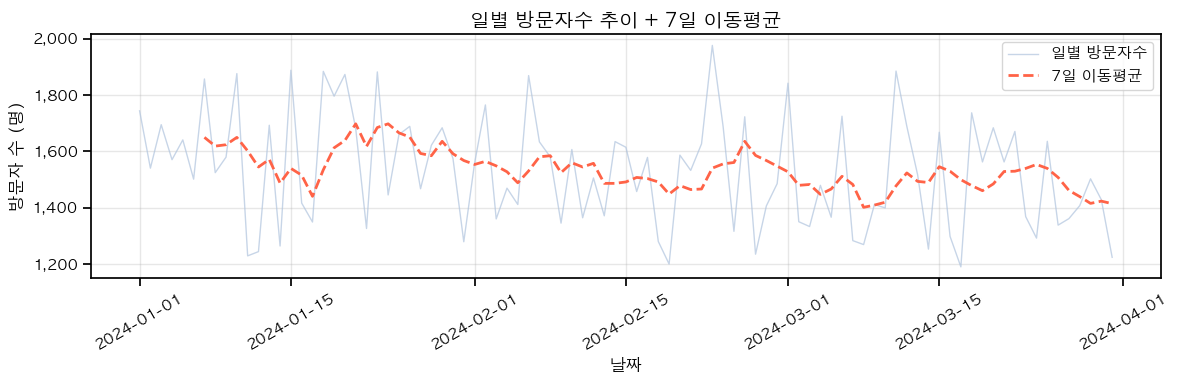

In [38]:
# [정답] 섹션 2 Exercise

fig, ax = plt.subplots(figsize=(12, 4))

# 1. 일별 방문자수 선 그래프
ax.plot(df_ts.index, df_ts['방문자수'],
        color='lightsteelblue', lw=1, alpha=0.7, label='일별 방문자수')

# 2. 7일 이동평균 — 빨간 점선
ax.plot(df_ts.index, df_ts['방문자_MA7'],
        color='tomato', lw=2, ls='--', label='7일 이동평균')

ax.set_title('일별 방문자수 추이 + 7일 이동평균', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('방문자 수 (명)')

# 3. Y축 천 단위 콤마
ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter('{x:,.0f}'))

ax.tick_params(axis='x', rotation=30)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 섹션 3 — 막대 그래프 Exercise 정답

> #### Exercise
> 1. **카테고리별 평균 수량**을 수직 막대 그래프로 그리시오. 막대 위에 평균 수량을 소수점 1자리로 표시하시오.
> 2. **지역별 주문 건수**를 수평 막대 그래프로 그리되, 건수가 **많은 순서**부터 위에 오도록 정렬하시오.
> 3. 분기별 총 매출을 **누적 막대 그래프**로 그리시오.

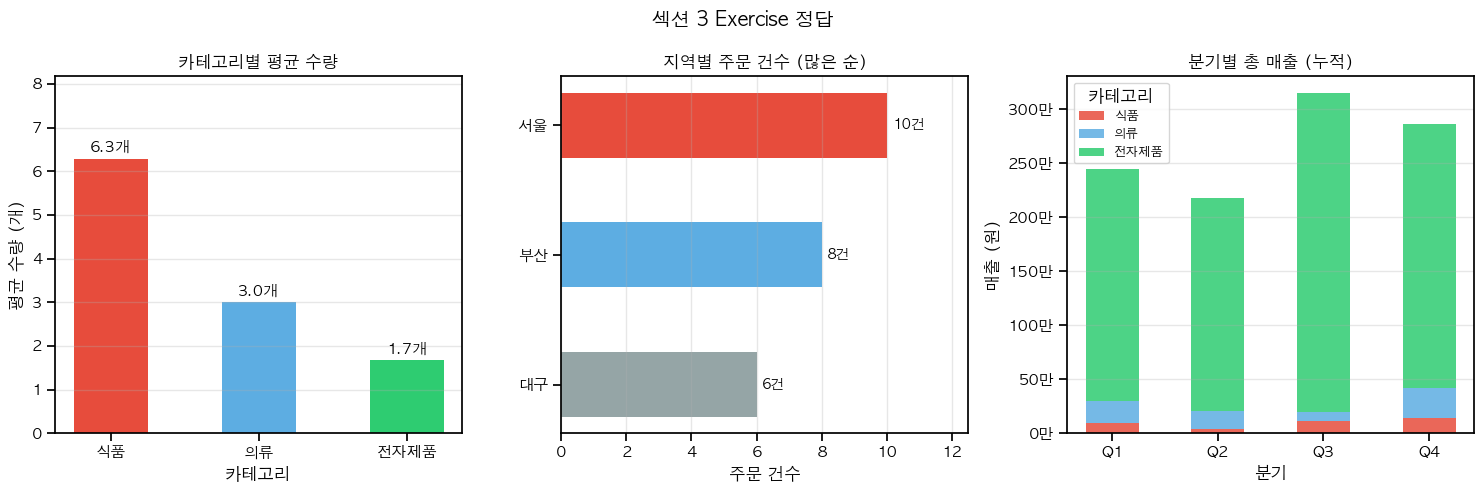

In [41]:
# [정답] 섹션 3 Exercise

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 1. 카테고리별 평균 수량 ──────────────────────────────
cat_qty = df_sales.groupby('카테고리')['수량'].mean().sort_values(ascending=False)

bars1 = axes[0].bar(cat_qty.index, cat_qty.values,
                    color=['#E74C3C','#5DADE2','#2ECC71'], width=0.5)

for bar in bars1:
    h = bar.get_height()
    axes[0].annotate(f'{h:.1f}개',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=11, fontweight='bold')

axes[0].set_title('카테고리별 평균 수량', fontsize=12, fontweight='bold')
axes[0].set_xlabel('카테고리')
axes[0].set_ylabel('평균 수량 (개)')
axes[0].set_ylim(0, cat_qty.max() * 1.3)
axes[0].grid(axis='y', alpha=0.3)

# ── 2. 지역별 주문 건수 (수평, 많은 순서 → 위) ─────────────
# barh는 위쪽이 마지막 인덱스 → 오름차순 정렬해야 위가 가장 큼
region_cnt = df_sales.groupby('지역')['주문ID'].count().sort_values(ascending=True)

bars2 = axes[1].barh(region_cnt.index, region_cnt.values,
                     color=['#95A5A6','#5DADE2','#E74C3C'], height=0.5)

for bar in bars2:
    w = bar.get_width()
    axes[1].annotate(f'{w:.0f}건',
                     xy=(w, bar.get_y() + bar.get_height()/2),
                     xytext=(4, 0), textcoords='offset points',
                     va='center', fontsize=10)

axes[1].set_title('지역별 주문 건수 (많은 순)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('주문 건수')
axes[1].set_xlim(0, region_cnt.max() * 1.25)
axes[1].grid(axis='x', alpha=0.3)

# ── 3. 분기별 총 매출 누적 막대 ──────────────────────────
pivot_cat_q = df_sales.pivot_table(
    values='매출', index='분기', columns='카테고리', aggfunc='sum', fill_value=0
)
categories_list = pivot_cat_q.columns.tolist()
colors_stack = ['#E74C3C','#5DADE2','#2ECC71']
x_q = pivot_cat_q.index
bottom = np.zeros(len(x_q))

for cat, color in zip(categories_list, colors_stack):
    axes[2].bar(x_q, pivot_cat_q[cat], bottom=bottom,
                label=cat, color=color, width=0.5, alpha=0.85)
    bottom += pivot_cat_q[cat].values

axes[2].set_title('분기별 총 매출 (누적)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('분기')
axes[2].set_ylabel('매출 (원)')
axes[2].yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
axes[2].legend(title='카테고리', fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('섹션 3 Exercise 정답', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

> #### Advance
> - 분기별 × 카테고리별 매출 피벗 → **누적 막대 그래프**, 각 막대 안에 카테고리 이름과 금액을 함께 표시하시오.

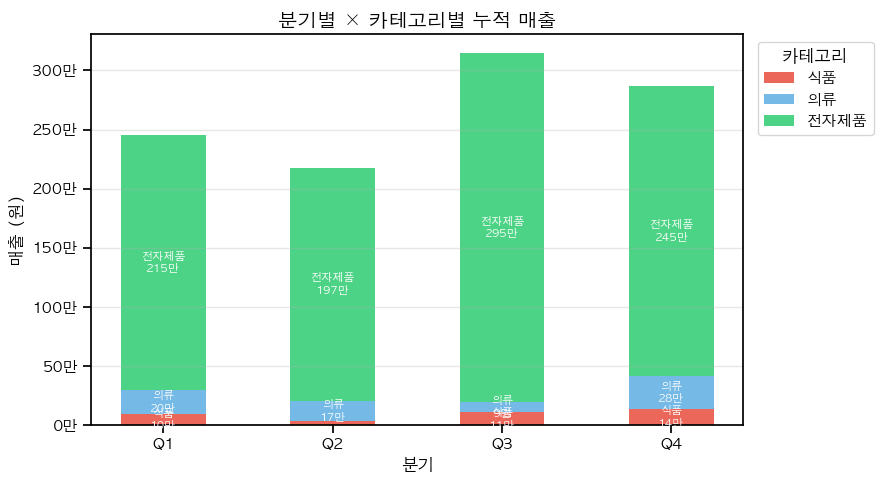

In [43]:
# [정답] 섹션 3 Advance — 누적 막대 + 내부 텍스트

pivot_cat_q = df_sales.pivot_table(
    values='매출', index='분기', columns='카테고리', aggfunc='sum', fill_value=0
)
categories_list = pivot_cat_q.columns.tolist()
colors_stack    = ['#E74C3C', '#5DADE2', '#2ECC71']
x_q = pivot_cat_q.index

fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(x_q))

for cat, color in zip(categories_list, colors_stack):
    vals = pivot_cat_q[cat].values
    bars = ax.bar(x_q, vals, bottom=bottom, label=cat,
                  color=color, width=0.5, alpha=0.85)

    # 막대 중간에 '카테고리명\nXXX만' 텍스트
    for bar, val in zip(bars, vals):
        mid_y = bar.get_y() + bar.get_height() / 2
        if val > 50000:   # 너무 작은 구간은 생략
            ax.text(bar.get_x() + bar.get_width() / 2, mid_y,
                    f'{cat}\n{val/10000:.0f}만',
                    ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')

    bottom += vals

ax.set_title('분기별 × 카테고리별 누적 매출', fontsize=14, fontweight='bold')
ax.set_xlabel('분기')
ax.set_ylabel('매출 (원)')
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f'{x/10000:.0f}만'))
ax.legend(title='카테고리', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 공통 실습 데이터 생성
10장 전체에서 사용하는 데이터셋을 한 번에 준비.

In [45]:
# Seaborn 내장 데이터셋
tips    = sns.load_dataset('tips')
titanic = sns.load_dataset('titanic')
tips = tips.rename(columns = {'sex':'gender'})
titanic = titanic.rename(columns = {'sex':'gender'})

# 8·9장 데이터 재생성
np.random.seed(42)
data_sales = {
    '주문ID':   [f'ORD-{i:04d}' for i in range(1, 25)],
    '지역':     ['서울','서울','부산','부산','대구','서울','부산','대구',
                 '서울','서울','부산','서울','대구','부산','대구','서울',
                 '부산','서울','대구','서울','부산','대구','서울','부산'],
    '카테고리':  ['전자제품','의류','전자제품','식품','의류','식품','전자제품','의류',
                 '식품','전자제품','의류','전자제품','식품','전자제품','의류','식품',
                 '전자제품','의류','전자제품','식품','의류','전자제품','식품','의류'],
    '분기':     ['Q1','Q1','Q1','Q1','Q1','Q1','Q2','Q2',
                 'Q2','Q2','Q2','Q3','Q3','Q3','Q3','Q3',
                 'Q3','Q4','Q4','Q4','Q4','Q4','Q4','Q4'],
    '매출':     [1200000,85000,950000,42000,120000,55000,870000,95000,
                 38000,1100000,76000,980000,61000,1050000,88000,49000,
                 920000,105000,1300000,72000,91000,1150000,66000,83000],
    '수량':     [2,3,1,5,2,4,1,3,6,2,4,1,7,2,3,5,1,2,3,8,4,2,9,3]
}
df_sales = pd.DataFrame(data_sales)

data_customer = {
    '고객ID':    [f'C{i:03d}' for i in range(1, 16)],
    '나이':      [23,35,42,28,51,19,67,31,44,56,38,25,72,48,33],
    '연간구매액': [850000,2300000,1500000,450000,3800000,120000,5200000,
                  1800000,2700000,4100000,950000,330000,6800000,3200000,1100000],
    '구매횟수':  [3,12,7,2,18,1,24,9,14,20,4,2,30,15,5]
}
df_cust = pd.DataFrame(data_customer)
df_cust['고객등급'] = pd.cut(df_cust['연간구매액'],
                             bins=[0,500000,1500000,3000000,float('inf')],
                             labels=['일반','실버','골드','VIP'])

# Advance용 이커머스 데이터
np.random.seed(42)
n = 300
categories_e = ['전자제품','의류/패션','식품/음료','생활용품','스포츠']
regions_e    = ['서울','경기','부산','대구','인천']
price_by_cat = {'전자제품':(200000,1500000),'의류/패션':(20000,200000),
                '식품/음료':(5000,80000),'생활용품':(8000,150000),'스포츠':(30000,500000)}
cat_list = np.random.choice(categories_e, size=n, p=[0.25,0.3,0.2,0.15,0.1])
prices   = np.array([np.random.randint(*price_by_cat[c]) for c in cat_list])
df_ecom = pd.DataFrame({
    '카테고리': cat_list,
    '지역':     np.random.choice(regions_e, size=n, p=[0.35,0.25,0.15,0.15,0.1]),
    '판매가':   prices,
    '수량':     np.random.randint(1, 5, size=n),
    '할인율':   np.random.choice([0,5,10,15,20], size=n, p=[0.4,0.2,0.2,0.1,0.1])
})
df_ecom['매출'] = (df_ecom['판매가'] * df_ecom['수량'] * (1 - df_ecom['할인율']/100)).astype(int)

cust_n = 100
df_cust_ecom = pd.DataFrame({
    '고객ID':    [f'C{i:03d}' for i in range(1, cust_n+1)],
    '연간구매액': np.random.randint(100000, 7000000, size=cust_n),
    '구매횟수':  np.random.randint(1, 35, size=cust_n)
})
df_cust_ecom['고객등급'] = pd.cut(
    df_cust_ecom['연간구매액'],
    bins=[0,500000,1500000,3000000,float('inf')],
    labels=['일반','실버','골드','VIP']
)

print('데이터 준비 완료')
print(f'  tips: {tips.shape}, titanic: {titanic.shape}')
print(f'  df_sales: {df_sales.shape}, df_cust: {df_cust.shape}')
print(f'  df_ecom: {df_ecom.shape}, df_cust_ecom: {df_cust_ecom.shape}')

데이터 준비 완료
  tips: (244, 7), titanic: (891, 15)
  df_sales: (24, 6), df_cust: (15, 5)
  df_ecom: (300, 6), df_cust_ecom: (100, 4)


---
## 섹션 3 — Axes-level 함수 Exercise 정답

> #### Exercise — Axes-level 함수
> `tips` 데이터셋을 사용하여 다음 그래프를 `plt.subplots(1, 3)`으로 나란히 그리시오.
> 1. `[0]`: `total_bill` 분포를 `hue='smoker'`로 구분한 **histplot** (kde=True)
> 2. `[1]`: `total_bill` vs `tip` 산점도를 `hue='time'`으로 구분한 **scatterplot** (size='size'도 추가)
> 3. `[2]`: `smoker` × `day` 별 `tip` 평균 **barplot** (x='smoker', hue='day')
> - 각 그래프에 `ax.set_title()`, `ax.set_xlabel()`, `ax.set_ylabel()` 추가

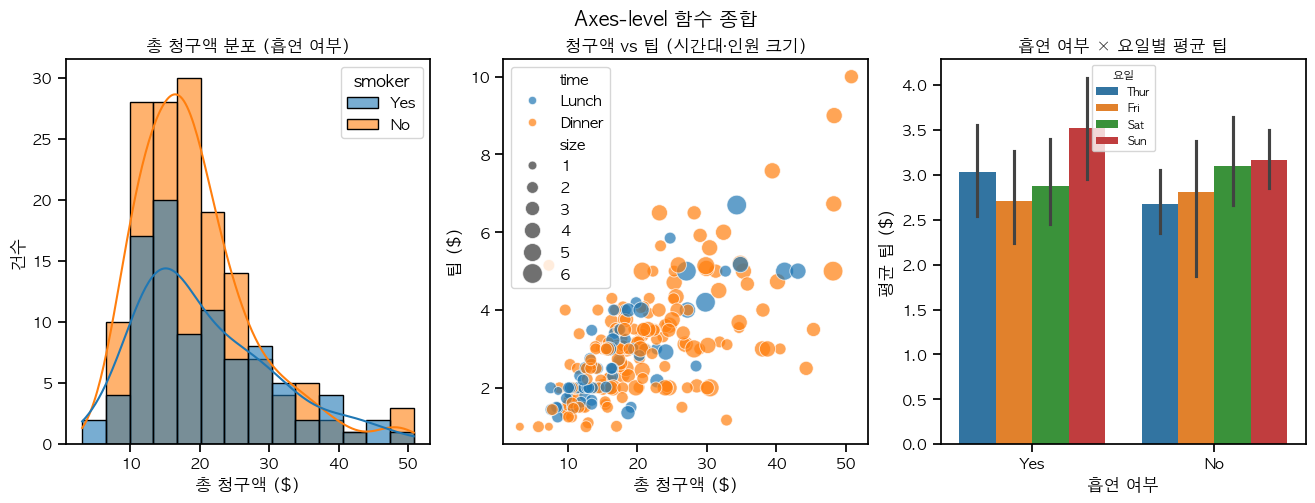

In [48]:
# [정답] 섹션 3 Exercise
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Axes-level 함수 종합', fontsize=14, fontweight='bold')

# 1. histplot — hue='smoker'
sns.histplot(data=tips, x='total_bill', hue='smoker',
             kde=True, alpha=0.6, ax=axes[0])
axes[0].set_title('총 청구액 분포 (흡연 여부)', fontsize=12)
axes[0].set_xlabel('총 청구액 ($)')
axes[0].set_ylabel('건수')

# 2. scatterplot — hue='time', size='size'
sns.scatterplot(data=tips, x='total_bill', y='tip',
                hue='time', size='size',
                sizes=(40, 200), alpha=0.7, ax=axes[1])
axes[1].set_title('청구액 vs 팁 (시간대·인원 크기)', fontsize=12)
axes[1].set_xlabel('총 청구액 ($)')
axes[1].set_ylabel('팁 ($)')

# 3. barplot — x='smoker', hue='day'
day_order = ['Thur','Fri','Sat','Sun']
sns.barplot(data=tips, x='smoker', y='tip',
            hue='day', hue_order=day_order, ax=axes[2])
axes[2].set_title('흡연 여부 × 요일별 평균 팁', fontsize=12)
axes[2].set_xlabel('흡연 여부')
axes[2].set_ylabel('평균 팁 ($)')
axes[2].legend(title='요일', fontsize=8, title_fontsize=8)
plt.show()

---
## 섹션 4 — Figure-level 함수 Exercise 정답

> #### Exercise — Figure-level 함수
> `titanic` 데이터셋을 사용하여 다음을 수행하시오.
> 1. `fare`(요금) 분포를 `hue='survived'`(생존 여부), `col='pclass'`(객실 등급)로 분할한 **displot** (kind='kde', fill=True)을 그리시오.
> 2. `pclass`별 `age` 분포를 `hue='gender'`로 구분한 **catplot** (kind='violin', split=True)을 그리시오.
> 3. `age` vs `fare` 산점도를 `hue='survived'`, `col='pclass'`로 분할한 **relplot**을 그리시오.
> - 각 Figure에 `g.figure.suptitle()`로 제목을 추가하시오.

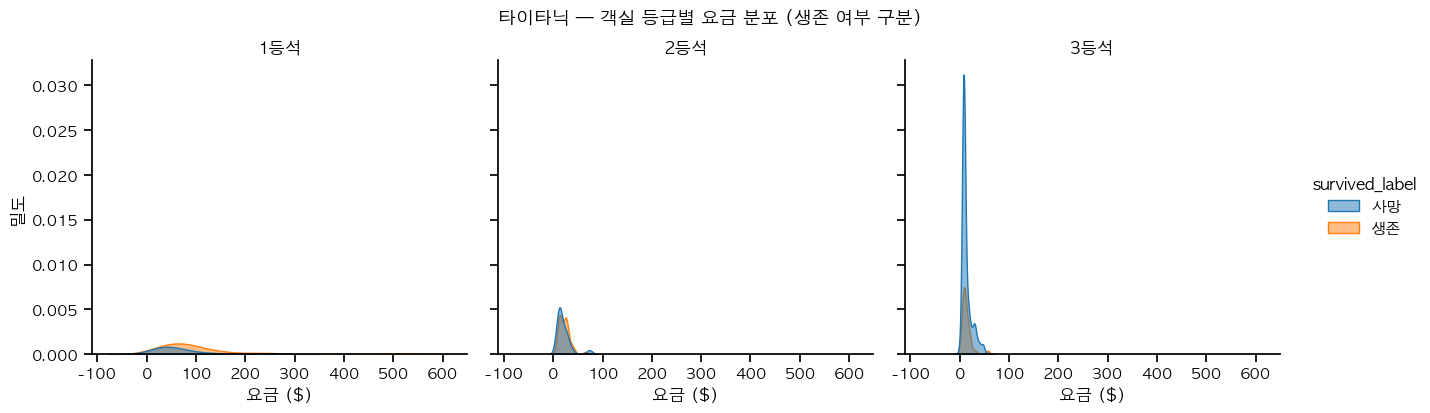

In [51]:
# [정답] 섹션 4 Exercise — 1. displot (fare 분포)
titanic_clean = titanic.dropna(subset=['age', 'fare'])
titanic_clean = titanic_clean.copy()
titanic_clean['survived_label'] = titanic_clean['survived'].map({0: '사망', 1: '생존'})

g1 = sns.displot(
    data=titanic_clean,
    x='fare',
    hue='survived_label',
    col='pclass',
    col_order=[1, 2, 3],
    kind='kde',
    fill=True,
    alpha=0.5,
    height=4, aspect=1.1
)
g1.set_axis_labels('요금 ($)', '밀도')
g1.set_titles('{col_name}등석')
g1.figure.suptitle('타이타닉 — 객실 등급별 요금 분포 (생존 여부 구분)', y=1.03, fontsize=13, fontweight='bold')
plt.show()